# Target
DNA sequence classification pipeline using k-mer tokenization, classical machine learning models, and a sequence-aware neural network based on TextVectorization, Embedding, and Conv1D. This script performs an end-to-end workflow for supervised classification of DNA sequences stored in a tabular dataset. It demonstrates both basic sequence inspection with Biopython and feature extraction for downstream modeling.

#Overview

1. Load DNA sequence data from ``human_data.txt``.
2. Inspect the dataset and one example sequence.
3. Compute basic sequence-derived properties such as sequence length and GC fraction.
4. Transform each DNA sequence into overlapping k-mers (default size = 6).
5. Convert k-mer lists into whitespace-delimited strings suitable for text-based
   vectorization.
6. Clean and validate class labels.
7. Evaluate several classical machine learning models using stratified
   cross-validation with leakage-safe pipelines:
   - Decision Tree
   - Random Forest
   - Multinomial Naive Bayes
8. Prepare a separate stratified train/test split for the neural-network section.
9. Convert the k-mer text into integer token sequences using TextVectorization.
10. Train a TensorFlow/Keras sequence-aware model with Embedding and Conv1D.
11. Plot training curves and report held-out test metrics.

# Expected input
The script expects a tab-separated file named ``human_data.txt`` in the current
working directory. At minimum, the file should contain:
- ``sequence``: DNA sequence strings
- ``class``: target class labels

# Important implementation notes
- K-mer extraction is case-normalized to uppercase.
- Cross-validation uses pipelines so the vectorizer is fit only on training
  folds, preventing data leakage.
- Invalid or non-numeric class labels are coerced to NaN and removed before
  model training.
- The neural-network section uses a separate randomized stratified train/test
  split rather than hard-coded row slicing.
- The neural network uses token sequences plus ``Embedding`` instead of
  bag-of-words counts, so local order information is preserved for ``Conv1D``.

# Dependencies
- Biopython
- pandas
- numpy
- matplotlib
- scikit-learn
- tensorflow

# Load Data & Import Libraries

In [ ]:
# Load Data
from google.colab import drive
drive.mount('/content/drive')
%pwd
%pip install bio
%cd /content/drive/MyDrive/'Colab Notebooks'

# Import all Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image
sns.set()

from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# ADD: specific evalution metrics
from sklearn.metrics import (
    accuracy_score, # overall corectness
    f1_score, # balance between precisions and recall
    precision_score, # how many predicted labels are corect
    recall_score, # how many true samples are correctly found
)

# ADD: In order to modify to a pipeline-based modeling
from sklearn.pipeline import make_pipeline

import tensorflow as tf
from tensorflow import keras

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.9 MB/s eta 0:00:00
/content/drive/MyDrive/Colab Notebooks


# Functions:
1.   **Get k-mers**: converts a DNA sequence into overlapping k-mers
2.   **Get metrics**: computes standard classification evaluation metrics
3.   **Evaluate with cv**: performs Stratified k-Fold Cross Validation (Splits the dataset into 5 folds, trains the model 5 times: each time trains 4 folds, tests 1 fold, keeps class distribution balanced). It's important because it reduces bias from a single train/test split, it gives more reliable permormance estimates and helps detect overfitting.
4.  **Plot training curves**: visualizes the training process of NN.


In [ ]:
# 1. getKmers
def getKmers(sequence, size=6):
    """
    Split a DNA sequence into overlapping k-mers.

    Example:
    sequence = "ATGCGA", size = 3
    returns ["ATG", "TGC", "GCG", "CGA"]
    """
    # Generate all contiguous subsequences of length 'size'.
    # '.upper()' normalizes tokens so mixed/lower-case input does not produce
    # duplicate vocabulary entries during vectorization.
    return [sequence[x:x+size].upper() for x in range(len(sequence) - size + 1)]

In [ ]:
# 2. get metrics
def get_metrics(y_test, y_predicted):
    """
    Compute standard weighted classification metrics.
    """
    # ADD: added zero_division=0 to avoid warnings/errors when a class is not predicted
    # 'weighted' means results acount for class imbalance
    accuracy = accuracy_score(y_test, y_predicted)
    precision = precision_score(y_test, y_predicted, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_predicted, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_predicted, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

In [ ]:
# ADD: 3. evaluate with cv
def evaluate_with_cv(model, X_text, y, model_name):
    """
    Evaluate a model with stratified 5-fold cross-validation.

    Parameters
    ----------
    model : sklearn-compatible estimator or pipeline
        Model object supporting 'fit' and 'predict'.
        In this script, a pipeline is used so text vectorization is performed
        separately inside each fold.
    X_text : pandas.Series
        Input samples represented as strings of k-mer tokens.
    y : array-like
        Target labels.
    model_name : str
        Label used when printing results.

    Notes
    -----
    StratifiedKFold preserves approximate class proportions in each fold.
    This is especially important for classification tasks with class imbalance.

    FIX: CountVectorizer is placed inside a pipeline and fit only on
    each training fold. This prevents data leakage from validation folds.
    """
    print(f"{model_name} :")

    # Stratification helps ensure each fold has a similar class distribution.
    # Shuffling plus a fixed random_state makes the evaluation reproducible.
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Iterate over each train/validation fold pair.
    for i, (train_index, val_index) in enumerate(skf.split(X_text, y)):
        # Select fold-specific training and validation text samples.
        X_train = X_text.iloc[train_index]
        X_val = X_text.iloc[val_index]

        # Select corresponding fold-specific labels.
        y_train = y[train_index]
        y_val = y[val_index]

        # Fit the full pipeline on the training fold only.
        model.fit(X_train, y_train)

        # Predict on the validation fold.
        pred = model.predict(X_val)

        # Compute and print fold metrics.
        accuracy, precision, recall, f1 = get_metrics(y_val, pred)
        print(f"{i} Iteration: Accuracy = {accuracy:.5f} Precision = {precision:.2f} Recall = {recall:.2f} F1_Score = {f1:.5f}")


In [ ]:
# ADD: 4. plots training curves
def plot_training_curves(history):
    """
    Plot training and validation loss/accuracy across epochs.

    Parameters
    ----------
    history : keras.callbacks.History
        The History object returned by 'model.fit()'.

    Notes
    -----
    - underfitting (If training and validation curve are both low)
    - overfitting (If training curve improves but validation worsens)
    - unstable optimization
    """
    plt.figure(figsize=(10, 4))

    # Loss
    plt.subplot(1, 2, 1)

    # Plot the training and validation loss recorded at each epoch.
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)

    # Plot the training and validation accuracy recorded at each epoch.
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Adjust spacing to prevent subplot labels/titles from overlapping.
    plt.tight_layout()
    plt.show()

# Neural Network

In [ ]:
# Load the tab-separated dataset into a pandas DataFrame.
# Expected columns include at least 'sequence' and 'class'.
humandata = pd.read_table('human_data.txt')

# Preview the first few rows to verify the dataset loaded correctly.
humandata.head()

# Print DataFrame schema and non-null counts for quick structural inspection.
humandata.info()

# Show the first raw DNA sequence.
humandata["sequence"][0]

# Report the length of the first example sequence.
print(f'length of Sequence 1 : {len(humandata["sequence"][0])}')

# Wrap the first sequence in a Biopython Seq object to demonstrate
# Sequence-aware operations such as complement and reverse complement.
my_seq = Seq(humandata["sequence"][0])
my_seq
print(f"Complement: {my_seq.complement()} \n")
print(f"Reverse Complement: {my_seq.reverse_complement()} ")

# FIX: update package name GC fraction is a basic compositional property often used in genomics.
print("gc_fraction% :\t" + str(gc_fraction(my_seq)*100))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sequence  4380 non-null   object
 1   class     4380 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 68.6+ KB
length of Sequence 1 : 207
Complement: TACGGGGTTGATTTATGATGGCATACCGGGTGGTATTAATGGGGGTATGAGGAATGTGATAAGGAGTAGTGGGTTGATTTTTATAATTTGTGTTTGATGGTGGATGGAGGGAGTGGTTTCGGGTATTTTTATTTTTTAATATTGTTTGGGACTCTTGGTTTTACTTGCTTTTAGACAAGCGAAGTAAGTAACGGGGGTGTTAGGATC 

Reverse Complement: CTAGGATTGTGGGGGCAATGAATGAAGCGAACAGATTTTCGTTCATTTTGGTTCTCAGGGTTTGTTATAATTTTTTATTTTTATGGGCTTTGGTGAGGGAGGTAGGTGGTAGTTTGTGTTTAATATTTTTAGTTGGGTGATGAGGAATAGTGTAAGGAGTATGGGGGTAATTATGGTGGGCCATACGGTAGTATTTAGTTGGGGCAT 
gc_fraction% :	39.61352657004831


,words,in_string
0,"[ATGCCC, TGCCCC, GCCCCA, CCCCAA, CCCAAC, CCAAC...",ATGCCC TGCCCC GCCCCA CCCCAA CCCAAC CCAACT CAAC...
1,"[ATGAAC, TGAACG, GAACGA, AACGAA, ACGAAA, CGAAA...",ATGAAC TGAACG GAACGA AACGAA ACGAAA CGAAAA GAAA...
2,"[ATGTGT, TGTGTG, GTGTGG, TGTGGC, GTGGCA, TGGCA...",ATGTGT TGTGTG GTGTGG TGTGGC GTGGCA TGGCAT GGCA...
3,"[ATGTGT, TGTGTG, GTGTGG, TGTGGC, GTGGCA, TGGCA...",ATGTGT TGTGTG GTGTGG TGTGGC GTGGCA TGGCAT GGCA...
4,"[ATGCAA, TGCAAC, GCAACA, CAACAG, AACAGC, ACAGC...",ATGCAA TGCAAC GCAACA CAACAG AACAGC ACAGCA CAGC...
...,...,...
4375,"[ATGGAA, TGGAAG, GGAAGA, GAAGAT, AAGATT, AGATT...",ATGGAA TGGAAG GGAAGA GAAGAT AAGATT AGATTT GATT...
4376,"[ATGCAG, TGCAGT, GCAGTC, CAGTCC, AGTCCT, GTCCT...",ATGCAG TGCAGT GCAGTC CAGTCC AGTCCT GTCCTT TCCT...
4377,"[ATGCAG, TGCAGT, GCAGTC, CAGTCC, AGTCCT, GTCCT...",ATGCAG TGCAGT GCAGTC CAGTCC AGTCCT GTCCTT TCCT...
4378,"[ATGGGG, TGGGGC, GGGGCA, GGGCAC, GGCACC, GCACC...",ATGGGG TGGGGC GGGGCA GGGCAC GGCACC GCACCT CACC...


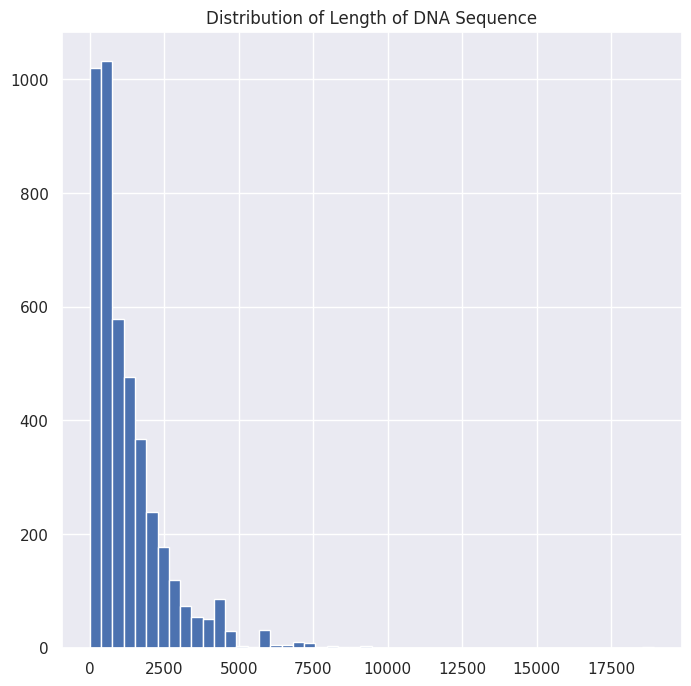

In [ ]:
# Finding the length of each DNA Sequence
# Add a new feature column containing the raw character length of each sequence.
humandata["length"] = humandata.sequence.apply(lambda x: len(x))

plt.figure(figsize=(8,8))
plt.hist(humandata["length"], bins=50)
plt.title("Distribution of Length of DNA Sequence");

# Now we can convert our training data sequences into short overlapping k-mers of legth 6.
# Each DNA sequence becomes a list of tokens, similar to words in an NLP task.
humandata['words'] = humandata.apply(lambda x: getKmers(x['sequence']), axis=1)
humandata.head()

# We are now going to Convert the words into string and then apply Count Vectorizer
# CountVectorizer expects text-like input, so we join each list of k-mers into
# a single whitespace-separated string.
humandata["in_string"] = humandata["words"].apply(lambda x: ' '.join(x))
humandata[["words", "in_string"]]

In [ ]:
# ADD: always coerce 'class' to numeric, not only when NaNs already exist.
# This catches hidden invalid strings and makes label handling robust.
print("Checking for NaNs and invalid class values...")

# Convert target labels to numeric values.
# Invalid strings will become NaN instead of causing downstream failures.
humandata['class'] = pd.to_numeric(humandata['class'], errors='coerce')

# Count how many rows now have missing/invalid class values.
nan_count = humandata['class'].isna().sum()
nan_count

# Print the problematic rows for transparency/debugging.
print(humandata[humandata['class'].isna()])

if nan_count > 0:
    # FIX: drop rows with invalid target labels before training.
    # Remove rows with missing target labels because supervised learning
    # requires a valid class for every training example.
    humandata = humandata.dropna(subset=['class']).copy()

# FIX: ensure labels are integers after cleaning.
# Cast class labels to integer type once cleaning is complete.
humandata['class'] = humandata['class'].astype(int)

Checking for NaNs and invalid class values...
Empty DataFrame
Columns: [sequence, class, length, words, in_string]
Index: []


In [ ]:
# ADD: remove exact duplicate DNA sequences before any split/evaluation.
# This prevents the same sequence from appearing multiple times across
# train/test partitions or cross-validation folds, which would inflate
# performance estimates and reduce robustness.
before_dedup = len(humandata)
humandata = humandata.drop_duplicates(subset=['sequence'], keep='first').copy()
removed_duplicates = before_dedup - len(humandata)
print(f"Removed exact duplicate sequences: {removed_duplicates}")
print(f"Rows remaining after deduplication: {len(humandata)}")

# Extract target labels as a NumPy array for scikit-learn and TensorFlow use.
y = humandata['class'].values

# Extract the tokenized-string representation used by text vectorizers.
X_text = humandata['in_string']

Removed exact duplicate sequences: 751
Rows remaining after deduplication: 3629


In [ ]:
# FIX: moved CountVectorizer into each pipeline so that vocabulary
# is learned only from the training fold during cross-validation.
# This prevents data leakage.
dt_pipeline = make_pipeline(
    # CountVectorizer(ngram_range=(4, 4)),
    # Use bigram token counts from the k-mer "text" as features.
    CountVectorizer(ngram_range=(2, 2), max_features=20000),

    # Decision tree classifier for a non-linear, interpretable baseline.
    DecisionTreeClassifier(random_state=42)
)

rf_pipeline = make_pipeline(
    # CountVectorizer(ngram_range=(4, 4)),
    # Same text feature extraction as above for a fairer model comparison.
    CountVectorizer(ngram_range=(2, 2), max_features=20000),

    # Random forest as an ensemble of decision trees.
    RandomForestClassifier(n_jobs=-1, random_state=42)
)

nb_pipeline = make_pipeline(
    # MultinomialNB is a natural fit for count-based text features.
    CountVectorizer(ngram_range=(2, 2), max_features=20000),
    MultinomialNB(alpha=0.1)
)

In [ ]:
# Evaluate each classical ML model using the same cross-validation setup.
evaluate_with_cv(dt_pipeline, X_text, y, "Decision Tree Classifier")
evaluate_with_cv(rf_pipeline, X_text, y, "Random Forest Classifier")

# FIX: removed the accidental 'break' so Naive Bayes now evaluates all folds.
evaluate_with_cv(nb_pipeline, X_text, y, "Naive Bayes Classifier")

Decision Tree Classifier :
0 Iteration: Accuracy = 0.69008 Precision = 0.69 Recall = 0.69 F1_Score = 0.69013
1 Iteration: Accuracy = 0.68320 Precision = 0.69 Recall = 0.68 F1_Score = 0.68264
2 Iteration: Accuracy = 0.70661 Precision = 0.71 Recall = 0.71 F1_Score = 0.70528
3 Iteration: Accuracy = 0.70523 Precision = 0.71 Recall = 0.71 F1_Score = 0.70571
4 Iteration: Accuracy = 0.69379 Precision = 0.70 Recall = 0.69 F1_Score = 0.69447
Random Forest Classifier :
0 Iteration: Accuracy = 0.85537 Precision = 0.88 Recall = 0.86 F1_Score = 0.85604
1 Iteration: Accuracy = 0.83747 Precision = 0.86 Recall = 0.84 F1_Score = 0.83747
2 Iteration: Accuracy = 0.85675 Precision = 0.88 Recall = 0.86 F1_Score = 0.85608
3 Iteration: Accuracy = 0.84986 Precision = 0.88 Recall = 0.85 F1_Score = 0.85137
4 Iteration: Accuracy = 0.85931 Precision = 0.88 Recall = 0.86 F1_Score = 0.86048
Naive Bayes Classifier :
0 Iteration: Accuracy = 0.84711 Precision = 0.85 Recall = 0.85 F1_Score = 0.84720
1 Iteration: Accura

In [ ]:
# FIX: replaced brittle manual slicing like [:4000] and [4001:4380]
# with a proper randomized stratified split.
# This avoids index errors, preserves class balance, and is more reliable.

# Create a reproducible train/test split with stratification so the class
# distribution is approximately preserved in both partitions.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,  # k-mer strings
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# FIX: replace CountVectorizer bag-of-words features for the neural-network
# section with integer token sequences that preserve k-mer order.
max_tokens = 20000
output_sequence_length = 300

vectorizer = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=output_sequence_length,
    standardize=None,
    split='whitespace'
)

# Adapt only on the training split to avoid leakage.
vectorizer.adapt(np.array(X_train_text))

X_train_seq = vectorizer(np.array(X_train_text)).numpy()
X_test_seq = vectorizer(np.array(X_test_text)).numpy()

print("Sequence train shape:", X_train_seq.shape)
print("Sequence test shape:", X_test_seq.shape)

# Infer data-driven model dimensions.
vocab_size = len(vectorizer.get_vocabulary())
num_classes = len(np.unique(y))

print("Vocabulary size:", vocab_size)
print("Number of classes:", num_classes)

Sequence train shape: (2903, 300)
Sequence test shape: (726, 300)
Vocabulary size: 4409
Number of classes: 7


In [ ]:
# Inspect a small sample of the learned token vocabulary.
for idx, token in enumerate(vectorizer.get_vocabulary()[:12]):
    print(f"{idx}: {token}")

print("NN training input shape:", X_train_seq.shape)
print("NN testing input shape:", X_test_seq.shape)

0: 
1: [UNK]
2: CTGCTG
3: CAGCAG
4: AGAAGA
5: CTGGAG
6: GAAGAA
7: CTGCAG
8: AAGAAG
9: GAGGAG
10: CCTGGA
11: TGCTGG
NN training input shape: (2903, 300)
NN testing input shape: (726, 300)


In [ ]:
# FIX: use a sequence-aware neural network:
# TextVectorization -> Embedding -> Conv1D -> GlobalMaxPooling -> Dense
model = keras.Sequential([
    keras.layers.Input(shape=(output_sequence_length,)),
    keras.layers.Embedding(input_dim=vocab_size, output_dim=128),
    keras.layers.Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

# Print a layer-by-layer summary of the neural-network architecture.
model.summary()

# Compile the model with Adam optimization and multiclass classification loss.
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
     monitor='val_loss',
     patience=2,
     restore_best_weights=True
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │       564,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 300, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 663,815 (2.53 MB)

 Trainable params: 663,815 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

# Training of Neural Network

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.2954 - loss: 1.7912 - val_accuracy: 0.3580 - val_loss: 1.6646
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.4961 - loss: 1.4596 - val_accuracy: 0.6145 - val_loss: 1.2523
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.6589 - loss: 1.0628 - val_accuracy: 0.6988 - val_loss: 0.9716
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.7606 - loss: 0.7502 - val_accuracy: 0.7728 - val_loss: 0.7766
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.8264 - loss: 0.5461 - val_accuracy: 0.7883 - val_loss: 0.6923
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.8910 - loss: 0.3775 - val_accuracy: 0.8141 - val_loss: 0.6117
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.9212 - loss: 0.2850 - val_accuracy: 0.8158 - val_loss: 0.6041
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.9457 - loss: 0.2069 - val_accuracy

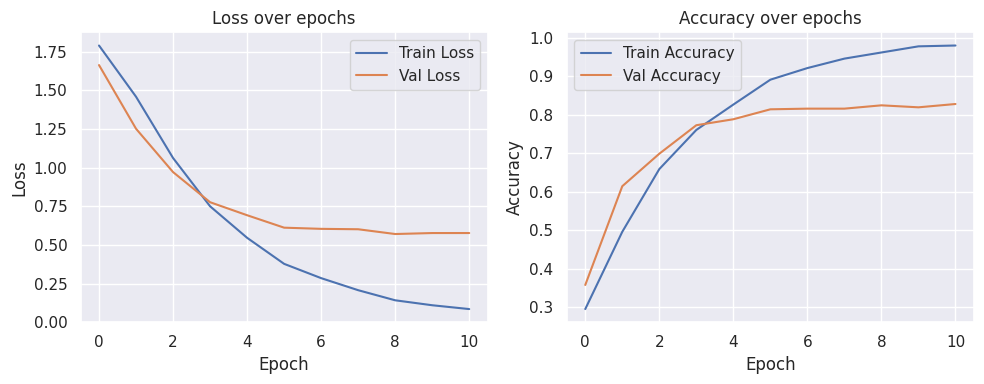

In [ ]:
# Train on the training split, while carving out a validation subset from
# within the training data to monitor generalization during training.
history = model.fit(
    x=X_train_seq,
    y=y_train,
    validation_split=0.2,
    shuffle=True,
    batch_size=32,
    epochs=20,
    verbose=1,
    callbacks=[early_stopping]
)

# Visualize optimization progress after training completes.
plot_training_curves(history)

In [ ]:
# FIX: use the proper held-out test set instead of hardcoded row slices.
# Generate class-probability predictions for the test split.
model_prediction = model.predict(X_test_seq)

# FIX: convert softmax probabilities to predicted class IDs with argmax(axis=1).
# Select the highest-probability class for each test sample.
y_pred_nn = np.argmax(model_prediction, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


# Results

In [ ]:
# Compute final held-out performance metrics for the neural network.
accuracy, precision, recall, f1 = get_metrics(y_test, y_pred_nn)
print(f"Test Accuracy = {accuracy:.5f} Test Precision = {precision:.2f} Test Recall = {recall:.2f} Test F1 Score = {f1:.5f}")

Test Accuracy = 0.82094 Test Precision = 0.83 Test Recall = 0.82 Test F1 Score = 0.81998
